---

Digital Brain

---

In [1]:
# import pgl commands
from pgl import pgl, pglExperiment, pglTask, pglParameter, pglKeyBuffer

# import libraries
import json
from pathlib import Path

# initialize pgl
pgl = pgl()
pgl.cleanUp()

================================ pglBase: init =================================
(pgl) mglMetal error log can be viewed in MacOS Console app by searching for PROCESS mglMetal or in a terminal with:
      log stream --level info --process mglMetal
(pgl) To search for something specifc, e.g. messages from mglMovie:
      log stream --predicate 'eventMessage CONTAINS "mglMovie"' --style syslog --level info
(pgl:checkOS) Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:35:20) [Clang 16.0.6 ]
(pgl:checkOS) Running on MacBook Pro (MacBookPro18,3) with macOS version: 26.6.2
(pgl:checkOS) Apple M1 Pro Cores: 8 (6 Performance and 2 Efficiency) Memory: 32 GB
(pgl:checkOS) GPU: Apple M1 Pro (Built-In) 14 cores, Metal 4 support
(pgl:checkOS)   Color LCD [Main Display]: 3024 x 1964 Retina (Built-in Liquid Retina XDR Display) GammaTable size: 1024
(pglBase) Main library instance created
(pglBase:removeOrphanedSockets) No orphaned sockets found in /Users/justin/Library/Contai

---

Display settings

---

In [2]:
pgl.displaySettings()

---

Settings

---

In [ ]:
pgl.settings()

---

Memory only task

---

In [ ]:
class pglDescriptionTask(pglTask):
    
    ########################
    def __init__(self, pgl):
        super().__init__(pgl)
        
        # initialize the key buffer
        self.keyBuffer = pglKeyBuffer(maxLineLength=40)
        
        # set task parameters, these will automatically be saved in the settings file
        self.settings.taskName = "Description Task"
        
        # set seglens
        self.settings.seglen = [2, float('inf'), 15]

        # fixed parameters, these will automatically be saved in the settings file
        self.settings.fixedParameters = {
            'movieDir':'/Users/justin/Movies/search',
            'captionFilename':'captions.json',
            'displayWidth': 30,
            
        }        
        p = self.settings.fixedParameters
        
        # load captions
        self.loadCaptions()
        
        # get movie names
        self.addParameter(pglParameter('movieFilename',list(self.data.captions.keys())))
        
    ########################
    def loadCaptions(self):
        '''
        Load captions from the JSON file.
        '''
        try:
            captionPath = Path(self.settings.fixedParameters['movieDir']) / self.settings.fixedParameters['captionFilename']
            with open(captionPath, 'r') as f:
                self.data.captions = json.load(f)
        except FileNotFoundError:
            print(f"Caption file {self.settings.fixedParameters['captionFilename']} not found.")
            self.data.captions = {}
            
        # check that all the movies exist
        for movieFilename, movieCaption in self.data.captions.items():
            # check that the file exists
            moviePath = Path(self.settings.fixedParameters['movieDir']) / movieFilename
            if not moviePath.exists():
                raise FileNotFoundError(f"(descriptionTask) Movie file {movieFilename} not found.")
            
    ########################
    def startSegment(self, startTime):
        '''
        Start a segment.
        '''
        super().startSegment(startTime)
        
        if self.state.currentSegment == 0:
            self.e.flush = True
            # do not eat keys
            self.e.setEatAllKeys(False)
            # load the movie
            moviePath = Path(self.settings.fixedParameters['movieDir']) / self.currentParams['movieFilename']
            self.m = pgl.movie(filename=str(moviePath),displayWidth=self.settings.fixedParameters['displayWidth'])
        elif self.state.currentSegment == 1:
            # play the movie
            #self.m.play(displayWidth=self.settings.fixedParameters['displayWidth'])
            self.jumpSegment()
        elif self.state.currentSegment == 2:
            # description segment
            self.e.setEatAllKeys(True)
            self.keyBuffer.clear()
            self.state.keyBufferDirty=False
            self.state.elapsedTime = -1
            self.e.flush = False
        
    ########################
    def updateScreen(self):
        if self.state.currentSegment == 0:
            caption = self.data.captions[self.currentParams['movieFilename']]
            self.pgl.text(caption, line="center")
        elif self.state.currentSegment == 2:
            # calcluate elapsed time
            elapsedTime = round(self.settings.seglen[self.state.currentSegment]-(self.pgl.getSecs()-self.state.segmentStartTime),0)
            
            # decide if we need to draw (only if elapsed time has changed or keyBufferDirty)
            if elapsedTime != self.state.elapsedTime or self.state.keyBufferDirty:
                # update elapsed time
                self.state.elapsedTime = elapsedTime
                # draw text
                self.pgl.text(f"Description Task: {elapsedTime:0.1f}", line="center")
            
                # draw the subject text
                text = self.keyBuffer.getWrappedText()
                for line in text.split('\n'):
                    self.pgl.text(line)
                self.state.keyBufferDirty = False
                
                # flush screen
                self.e.pgl.flush()
    
    ########################
    def handleEvents(self, events):
        for event in events:
            if event.eventType == 'keydown':
                self.keyBuffer.processEvent(event)
                self.state.keyBufferDirty = True


---

Initialize task

---

In [7]:
# Set up experiment
e = pglExperiment(pgl, experimentName="Digital Brain Memory pilot")

# initialize tasks
descriptionTask = pglDescriptionTask(pgl)

# add the tasks to the experiment
e.addTask(descriptionTask)

---

Run task

---

(pglBase:removeOrphanedSockets) No orphaned sockets found in /Users/justin/Library/Containers/gru.mglMetal/Data
================================= pglBase:open =================================
(pgl:_resolution:getResolution) Display 0/1: 1512x982 120Hz 32bits
(pglBase:getMetalAppName) Using latest build: /Users/justin/Library/Developer/Xcode/DerivedData/Build/Products/Release/mglMetal.app
(pgl->pglBase:open) Starting mglMetal application: /Users/justin/Library/Developer/Xcode/DerivedData/Build/Products/Release/mglMetal.app
(pgl->pglBase:open) Using socket with address: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260821_224252.IPcqhN9Onh
(pgl:_pglComm) .Connected to: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260821_224252.IPcqhN9Onh
(pgl:_resolution:getResolution) Display 0/1: 1512x982 120Hz 32bits
(pglKeyboardMouse:start) Starting keyboard and mouse event listener.
(pglEventListener) Eating 7 keys: ['1', '2', '3', '4', '`', 'escape', 

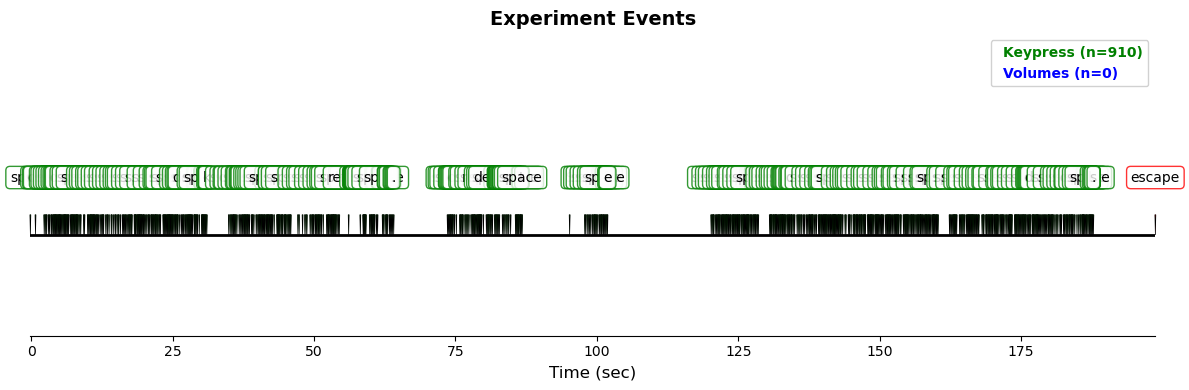

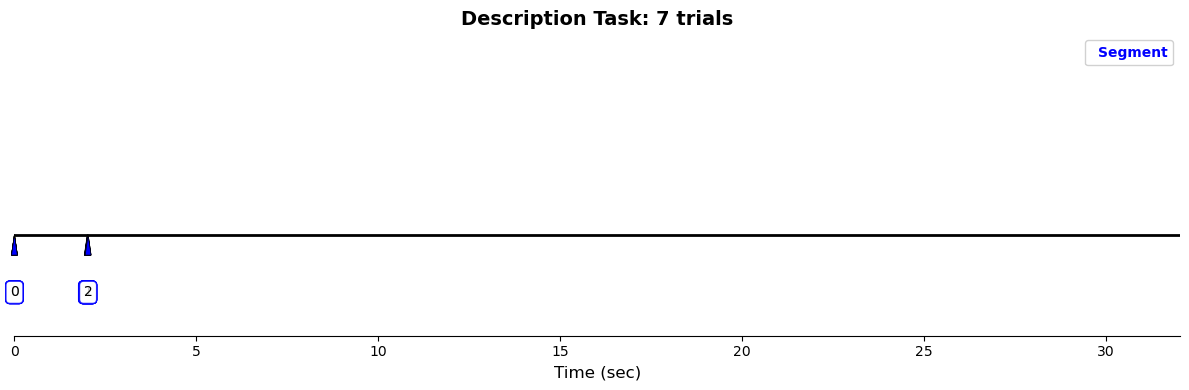

In [8]:
# initialize screen
e.initScreen()

# and run the experiment
e.run()

# display results
e.display()